# 🔋 Energy AI Hackathon 2026 — Notebook 1: EDA & Feature Engineering
**Solship | Zewail City of Science and Technology**

---
### Pipeline Overview
- Optimizer window = **1 day (96 timesteps)**
- All lag features use **≥ 96 steps (≥ 24 hours)** — fully causal, no intra-day leakage
- Forecaster predicts the next full day → optimizer plans battery dispatch for the whole day

### Sections
1. Install & Import Libraries
2. Load Raw Data (2024 only)
3. Data Quality & Integrity Checks
4. Exploratory Data Analysis (EDA)
5. PACF Analysis
6. Weather Data (2024)
7. Feature Engineering (2024)
8. Save 2024 Features
9. 2025 EDA & Feature Engineering
10. Save 2025 Features
---

## 1. Install & Import Libraries

In [ ]:
!pip install xgboost lightgbm scikit-learn holidays statsmodels --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import holidays
import json
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import pacf

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load Raw Data (2024 only)

In [ ]:
df_raw = pd.read_csv('/content/ENERGY_Hackathon_DataSet_Sheet1.csv', sep=';', decimal=',')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)
df_raw = df_raw.rename(columns={
    'battery_p'            : 'p_battery_kw',
    'grid_p'               : 'p_grid_kw',
    'load_p'               : 'load_kw',
    'pv_p'                 : 'pv_kw',
    'Selling_price_eur_kwh': 'sell_price'
})

# Keep 2024 only for training pipeline
df_raw = df_raw[df_raw['timestamp'].dt.year == 2024].reset_index(drop=True)
df_raw['sell_price'] = df_raw['sell_price'].fillna(method='ffill')

print(f'Shape     : {df_raw.shape}')
print(f'Columns   : {df_raw.columns.tolist()}')
print(f'Date range: {df_raw.timestamp.min()} → {df_raw.timestamp.max()}')
print(f'Rows      : {len(df_raw)}')
df_raw.head()

Shape     : (35136, 6)
Columns   : ['p_battery_kw', 'p_grid_kw', 'load_kw', 'pv_kw', 'timestamp', 'sell_price']
Date range: 2024-01-01 00:00:00 → 2024-12-31 23:45:00
Rows      : 35136


,p_battery_kw,p_grid_kw,load_kw,pv_kw,timestamp,sell_price
0,0.0000,3.0400,3.0500,0.0000,2024-01-01 00:00:00,0.1071
1,0.0000,0.3400,0.3400,0.0000,2024-01-01 00:15:00,0.1071
2,0.0000,0.3700,0.3700,0.0000,2024-01-01 00:30:00,0.1071
3,0.0000,0.3700,0.3700,0.0000,2024-01-01 00:45:00,0.1071
4,0.0000,2.4000,2.4000,0.0000,2024-01-01 01:00:00,0.1040


## 3. Data Quality & Integrity Checks

In [ ]:
# ── 3.1 Missing Values ─────────────────────────────────────────
print('=== Missing Values ===')
print(df_raw.isnull().sum())

=== Missing Values ===
p_battery_kw    0
p_grid_kw       0
load_kw         0
pv_kw           0
timestamp       0
sell_price      0
dtype: int64


In [ ]:
# ── 3.2 Timestamp Continuity ───────────────────────────────────
expected_range = pd.date_range(start=df_raw.timestamp.min(),
                                end=df_raw.timestamp.max(),
                                freq='15min')
missing_ts = expected_range.difference(df_raw['timestamp'])
print(f'Expected intervals : {len(expected_range)}')
print(f'Actual rows        : {len(df_raw)}')
print(f'Missing timestamps : {len(missing_ts)}')
if len(missing_ts) > 0:
    print(missing_ts)

Expected intervals : 35136
Actual rows        : 35136
Missing timestamps : 4
DatetimeIndex(['2024-03-31 02:00:00', '2024-03-31 02:15:00',
               '2024-03-31 02:30:00', '2024-03-31 02:45:00'],
              dtype='datetime64[ns]', freq='15min')


In [ ]:
# ── 3.3 Physical Range Checks ──────────────────────────────────
print('=== Physical Range Checks ===')
checks = {
    'load_kw < 0'          : (df_raw['load_kw'] < 0).sum(),
    'pv_kw < 0'            : (df_raw['pv_kw'] < 0).sum(),
    'pv_kw > 9 (cap 9kWp)' : (df_raw['pv_kw'] > 9).sum(),
    '|p_battery_kw| > 8'   : (df_raw['p_battery_kw'].abs() > 8).sum(),
    '|p_grid_kw| > 6.5'    : (df_raw['p_grid_kw'].abs() > 6.5).sum(),
}
for k, v in checks.items():
    flag = '⚠️' if v > 0 else '✅'
    print(f'  {flag}  {k}: {v} violations')

print()
print('=== Descriptive Stats ===')
df_raw[['load_kw','pv_kw','p_battery_kw','p_grid_kw','sell_price']].describe()

=== Physical Range Checks ===
  ✅  load_kw < 0: 0 violations
  ✅  pv_kw < 0: 0 violations
  ✅  pv_kw > 9 (cap 9kWp): 0 violations
  ✅  |p_battery_kw| > 8: 0 violations
  ⚠️  |p_grid_kw| > 6.5: 12 violations

=== Descriptive Stats ===


,load_kw,pv_kw,p_battery_kw,p_grid_kw,sell_price
count,35136.0000,35136.0000,35136.0000,35136.0000,35136.0000
mean,1.4884,1.0607,-0.0033,0.4307,0.1074
std,1.2595,1.7861,1.1403,1.3039,0.0284
min,0.0000,0.0000,-5.0800,-5.9200,0.0001
25%,0.3600,0.0000,0.0000,0.0000,0.0917
50%,1.1400,0.0000,0.0000,0.0100,0.1051
75%,2.3600,1.4900,0.3400,0.6300,0.1206
max,9.2600,8.5500,5.0200,9.0900,0.2770


In [ ]:
# ── 3.4 Energy Balance Check ───────────────────────────────────
df_raw['balance_error'] = df_raw['load_kw'] - (df_raw['pv_kw'] + df_raw['p_grid_kw'] + df_raw['p_battery_kw'])
print('Energy balance error stats (should be near zero):')
print(df_raw['balance_error'].describe())
threshold = 0.5
bad_balance = (df_raw['balance_error'].abs() > threshold).sum()
print(f'\nTimesteps with |balance_error| > {threshold} kW: {bad_balance} ({bad_balance/len(df_raw)*100:.2f}%)')
df_raw['balance_ok'] = df_raw['balance_error'].abs() <= threshold

Energy balance error stats (should be near zero):
count   35136.0000
mean        0.0003
std         0.0060
min        -0.6800
25%         0.0000
50%         0.0000
75%         0.0000
max         0.0200
Name: balance_error, dtype: float64

Timesteps with |balance_error| > 0.5 kW: 1 (0.00%)


In [ ]:
# ── 3.5 Duplicate Timestamps ───────────────────────────────────
dups = df_raw.duplicated(subset='timestamp').sum()
print(f'Duplicate timestamps: {dups}')
if dups > 0:
    df_raw = df_raw.drop_duplicates(subset='timestamp').reset_index(drop=True)
    print('Duplicates dropped.')
print(f'Final shape: {df_raw.shape}')

Duplicate timestamps: 4
Duplicates dropped.
Final shape: (35132, 8)


## 4. Exploratory Data Analysis (EDA)

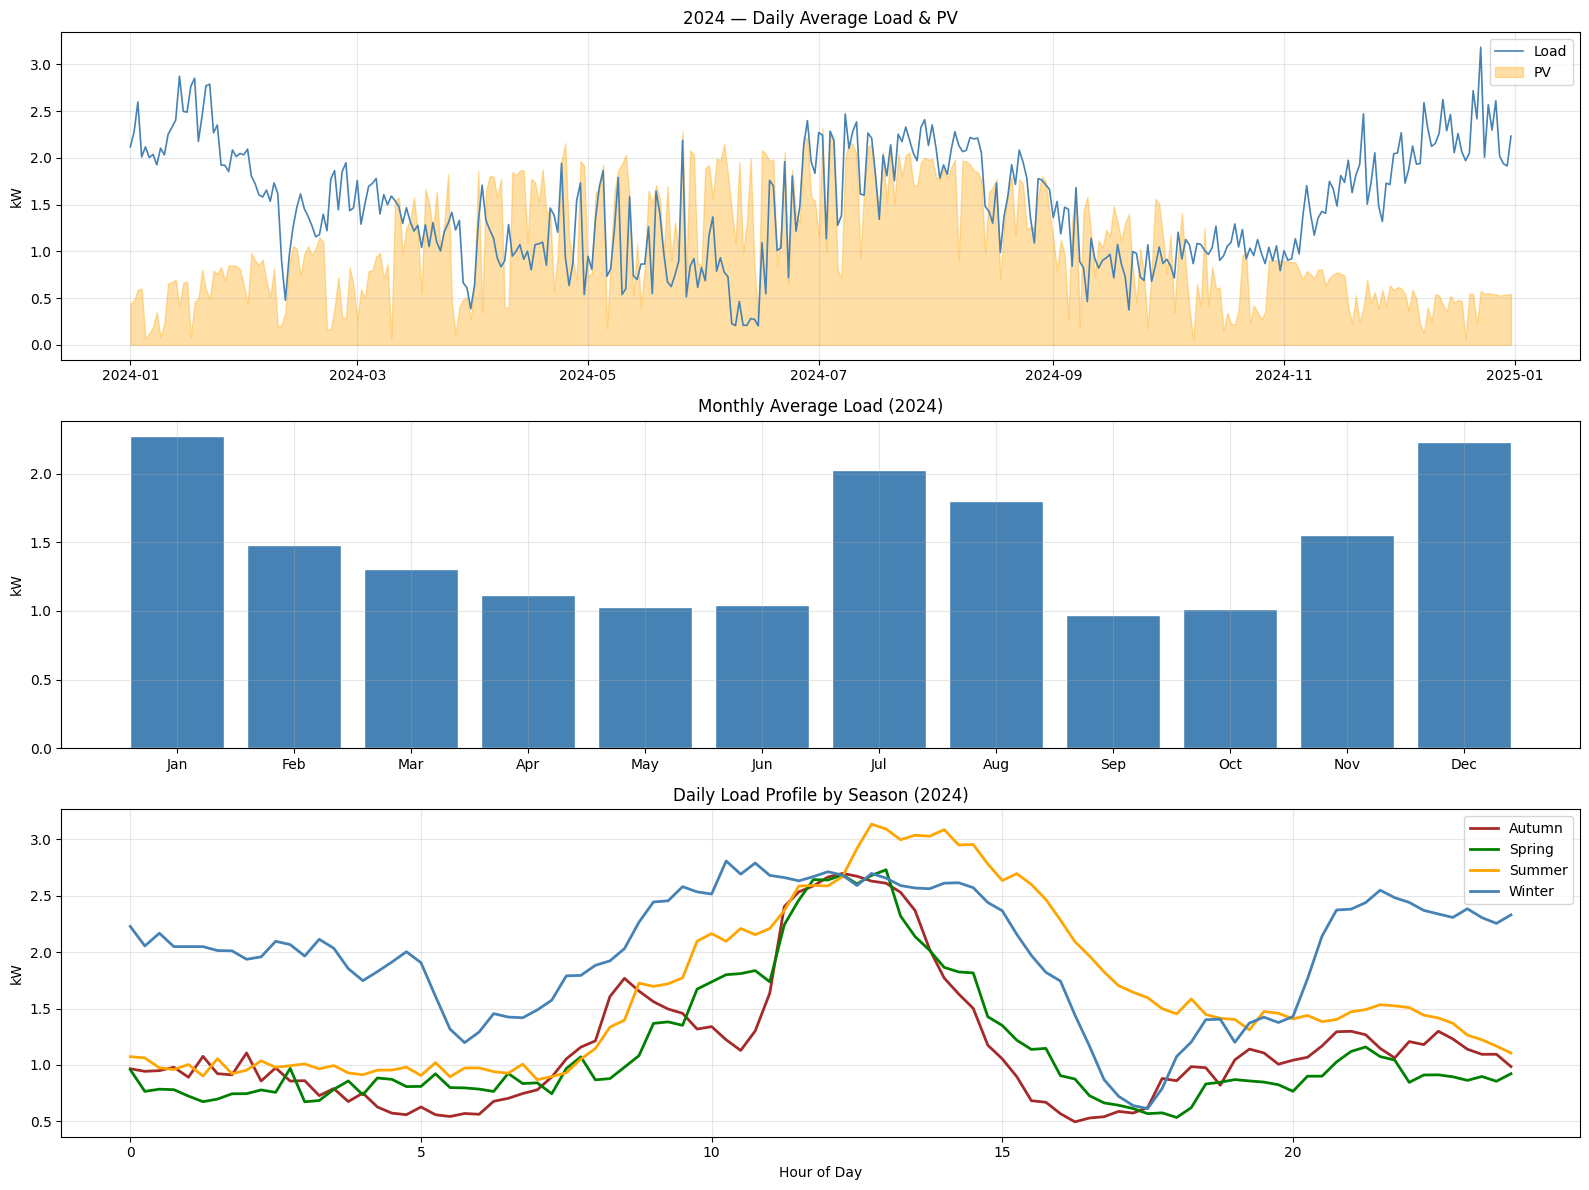

In [ ]:
df_2024 = df_raw.copy()
df_2024['month']  = df_2024['timestamp'].dt.month
df_2024['dow']    = df_2024['timestamp'].dt.dayofweek
df_2024['hour']   = df_2024['timestamp'].dt.hour

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Daily avg load & PV
daily = df_2024.set_index('timestamp').resample('D')[['load_kw','pv_kw']].mean()
axes[0].plot(daily.index, daily['load_kw'], label='Load', color='steelblue', linewidth=1.2)
axes[0].fill_between(daily.index, daily['pv_kw'], alpha=0.35, color='orange', label='PV')
axes[0].set_title('2024 — Daily Average Load & PV')
axes[0].set_ylabel('kW')
axes[0].legend()

# Monthly avg
monthly = df_2024.groupby('month')['load_kw'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Monthly Average Load (2024)')
axes[1].set_ylabel('kW')

# Seasonal profiles
def get_season(m):
    if m in [12,1,2]: return 'Winter'
    elif m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    else: return 'Autumn'

df_2024['season'] = df_2024['month'].apply(get_season)
colors = {'Winter':'steelblue','Spring':'green','Summer':'orange','Autumn':'brown'}
for season, grp in df_2024.groupby('season'):
    profile = grp.groupby(grp['timestamp'].dt.hour + grp['timestamp'].dt.minute/60)['load_kw'].mean()
    axes[2].plot(profile.index, profile.values, label=season, color=colors[season], linewidth=2)
axes[2].set_title('Daily Load Profile by Season (2024)')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('kW')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_01_overview.png', dpi=120, bbox_inches='tight')
plt.show()

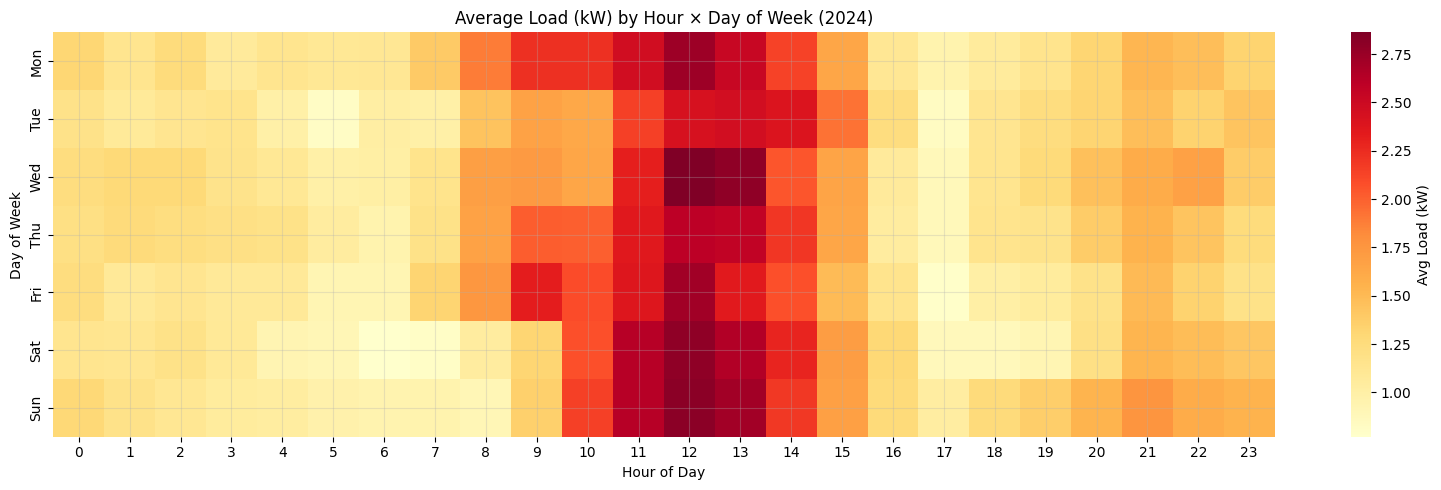

In [ ]:
# ── Heatmap: Hour × Day of Week ───────────────────────────────
pivot = df_2024.groupby(['dow','hour'])['load_kw'].mean().unstack()
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, yticklabels=day_labels,
            cbar_kws={'label':'Avg Load (kW)'})
ax.set_title('Average Load (kW) by Hour × Day of Week (2024)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('eda_02_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

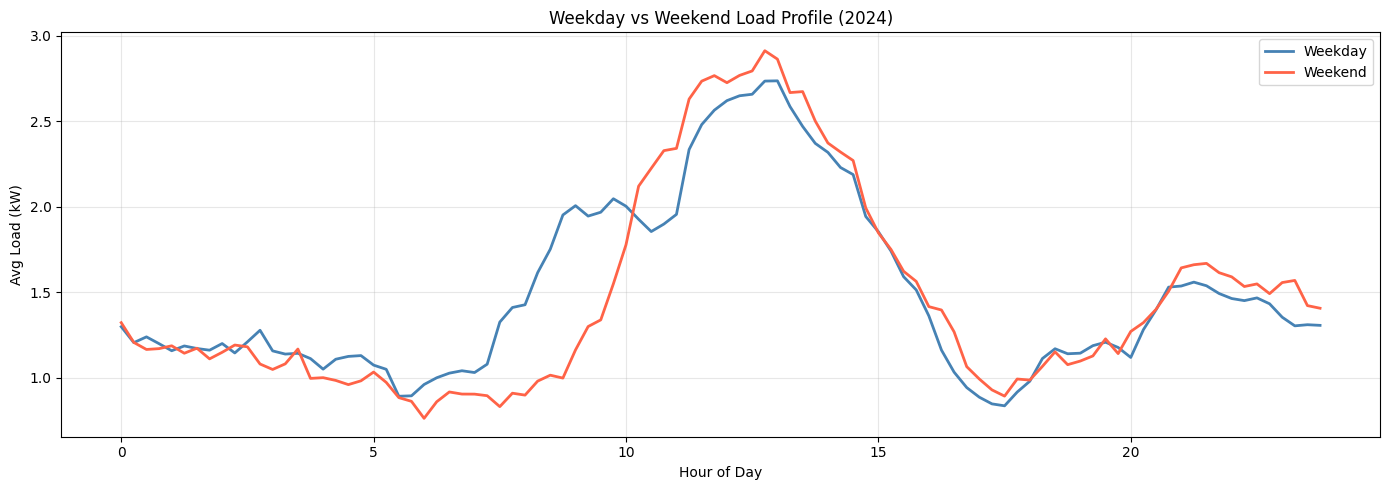

In [ ]:
# ── Weekday vs Weekend Profile ─────────────────────────────────
df_2024['is_weekend'] = df_2024['dow'] >= 5
fig, ax = plt.subplots(figsize=(14, 5))
for flag, label, color in [(False,'Weekday','steelblue'),(True,'Weekend','tomato')]:
    subset  = df_2024[df_2024['is_weekend'] == flag]
    profile = subset.groupby(subset['timestamp'].dt.hour + subset['timestamp'].dt.minute/60)['load_kw'].mean()
    ax.plot(profile.index, profile.values, label=label, color=color, linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Load (kW)')
ax.set_title('Weekday vs Weekend Load Profile (2024)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_03_weekday_weekend.png', dpi=120, bbox_inches='tight')
plt.show()

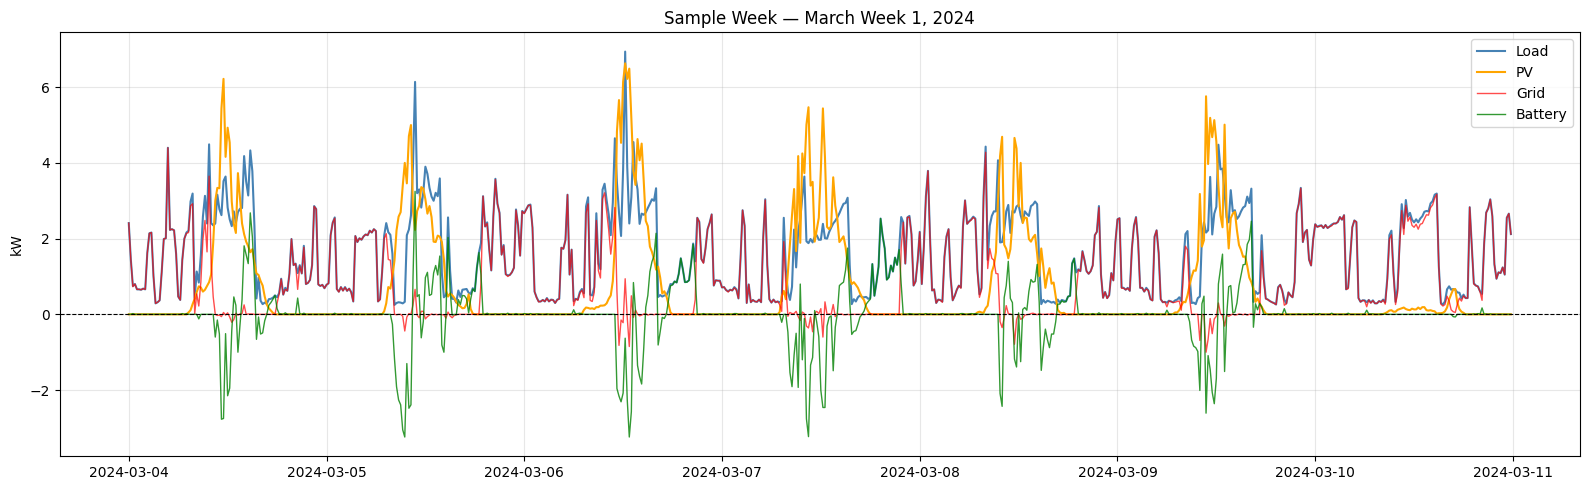

In [ ]:
# ── Sample Week ────────────────────────────────────────────────
sample = df_2024[(df_2024['timestamp'] >= '2024-03-04') & (df_2024['timestamp'] < '2024-03-11')]
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample['timestamp'], sample['load_kw'],      label='Load',    color='steelblue', linewidth=1.5)
ax.plot(sample['timestamp'], sample['pv_kw'],        label='PV',      color='orange',    linewidth=1.5)
ax.plot(sample['timestamp'], sample['p_grid_kw'],    label='Grid',    color='red',       linewidth=1, alpha=0.7)
ax.plot(sample['timestamp'], sample['p_battery_kw'], label='Battery', color='green',     linewidth=1, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Sample Week — March Week 1, 2024')
ax.set_ylabel('kW')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04_sample_week.png', dpi=120, bbox_inches='tight')
plt.show()

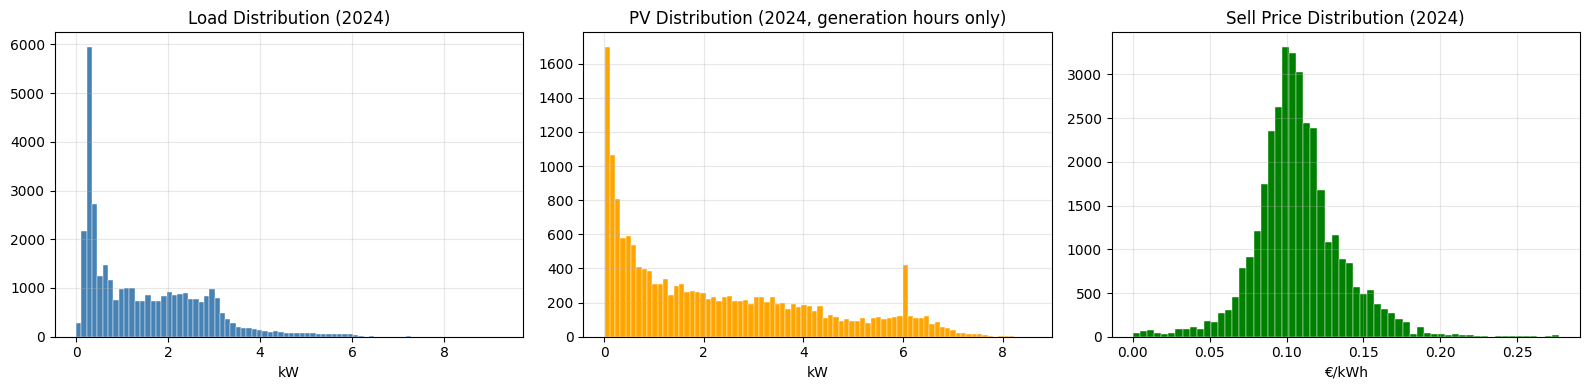

In [ ]:
# ── Distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df_2024['load_kw'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Load Distribution (2024)')
axes[0].set_xlabel('kW')
axes[1].hist(df_2024['pv_kw'][df_2024['pv_kw'] > 0], bins=80, color='orange', edgecolor='white', linewidth=0.3)
axes[1].set_title('PV Distribution (2024, generation hours only)')
axes[1].set_xlabel('kW')
axes[2].hist(df_2024['sell_price'], bins=60, color='green', edgecolor='white', linewidth=0.3)
axes[2].set_title('Sell Price Distribution (2024)')
axes[2].set_xlabel('€/kWh')
plt.tight_layout()
plt.savefig('eda_05_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

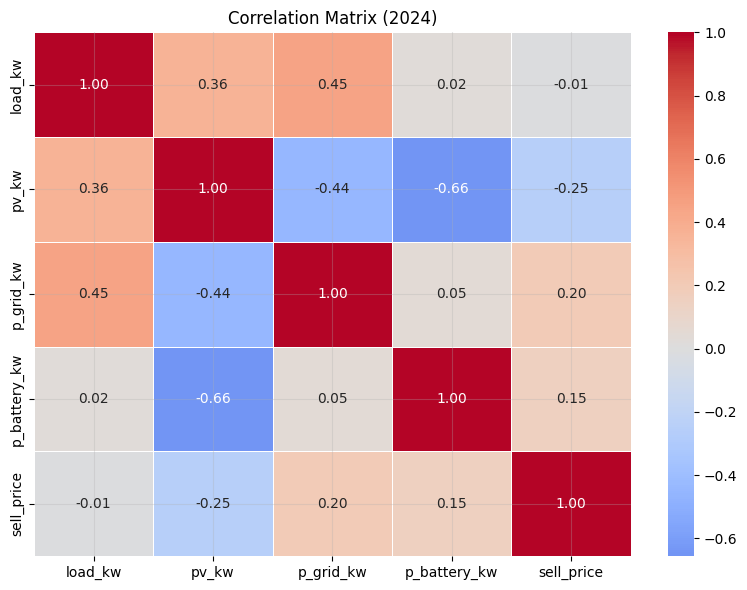

In [ ]:
# ── Correlation Matrix ─────────────────────────────────────────
corr_cols = ['load_kw','pv_kw','p_grid_kw','p_battery_kw','sell_price']
corr = df_2024[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (2024)')
plt.tight_layout()
plt.savefig('eda_06_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. PACF Analysis

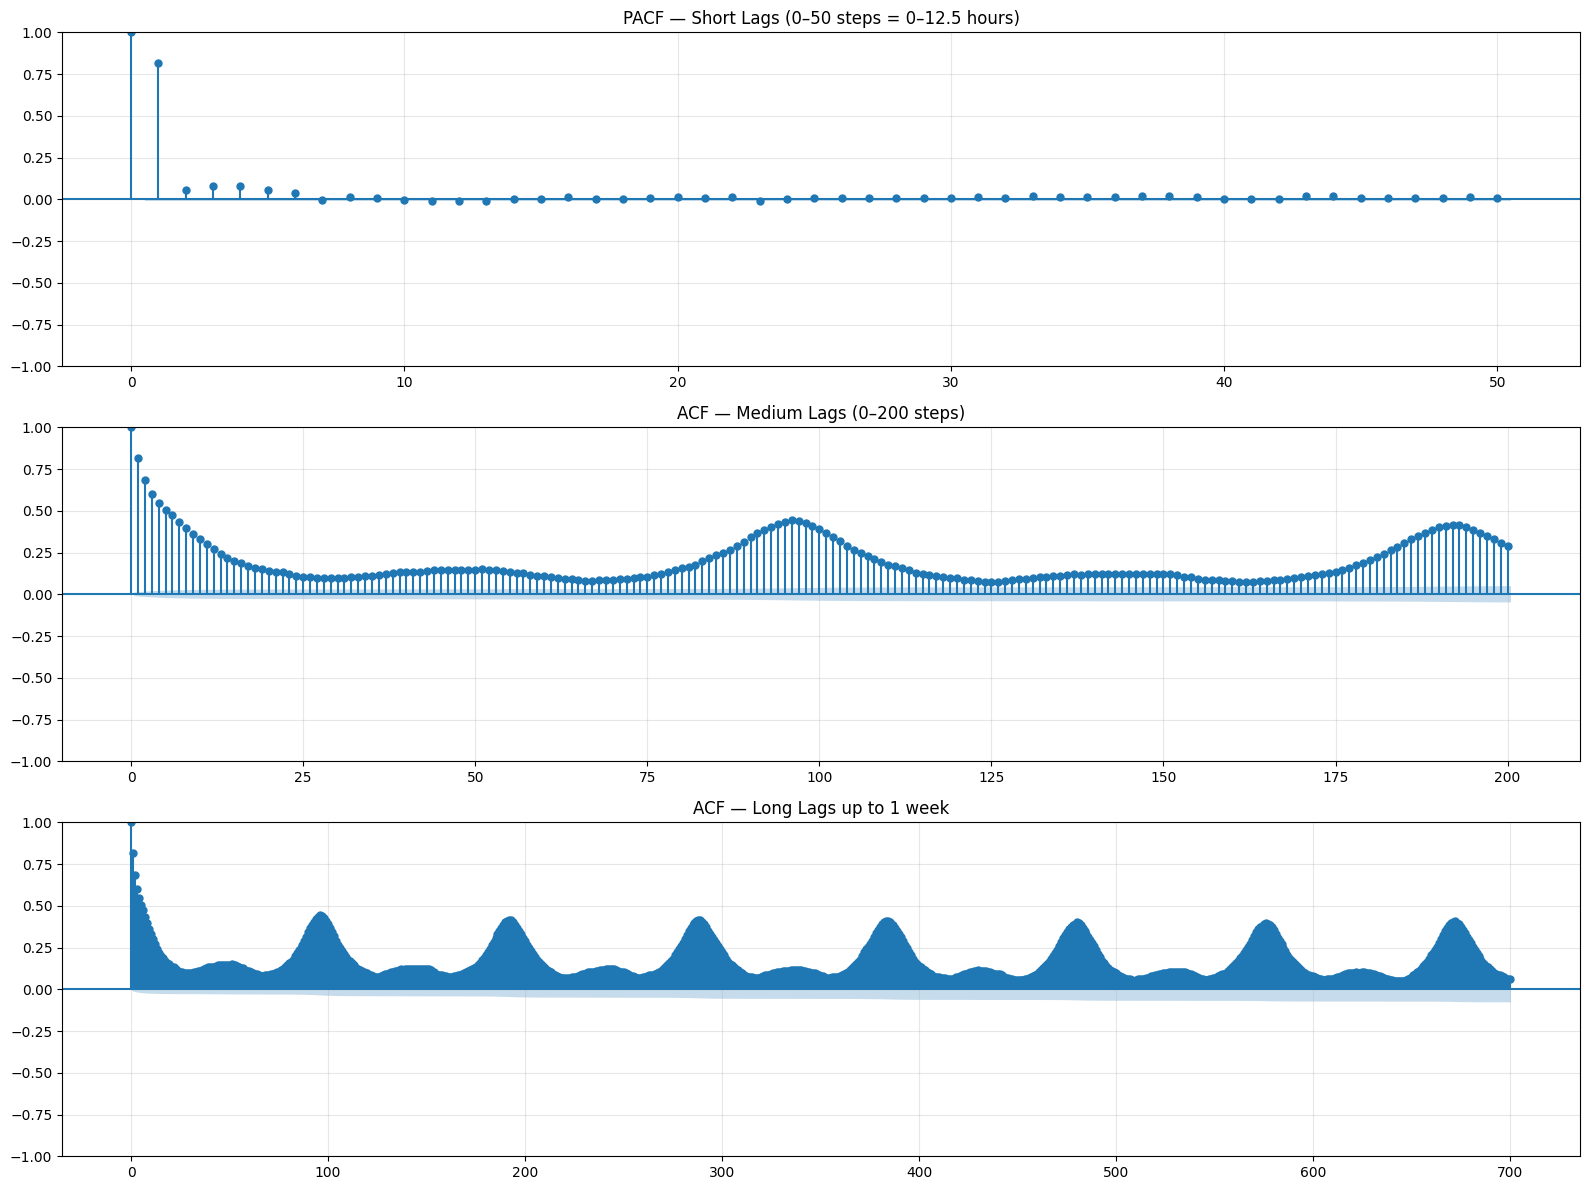

Significant PACF lags (up to lag 100):
  lag   0  (0 min)  →  PACF = 1.0000
  lag   1  (15 min)  →  PACF = 0.8158
  lag   2  (30 min)  →  PACF = 0.0547
  lag   3  (45 min)  →  PACF = 0.0793
  lag   4  (60 min)  →  PACF = 0.0799
  lag   5  (75 min)  →  PACF = 0.0546
  lag   6  (90 min)  →  PACF = 0.0349
  lag   8  (120 min)  →  PACF = 0.0122
  lag  13  (195 min)  →  PACF = -0.0111
  lag  16  (240 min)  →  PACF = 0.0137
  lag  20  (300 min)  →  PACF = 0.0127
  lag  22  (330 min)  →  PACF = 0.0116
  lag  31  (465 min)  →  PACF = 0.0140
  lag  33  (495 min)  →  PACF = 0.0176
  lag  34  (510 min)  →  PACF = 0.0111
  lag  35  (525 min)  →  PACF = 0.0131
  lag  36  (540 min)  →  PACF = 0.0124
  lag  37  (555 min)  →  PACF = 0.0227
  lag  38  (570 min)  →  PACF = 0.0170
  lag  39  (585 min)  →  PACF = 0.0116
  lag  43  (645 min)  →  PACF = 0.0179
  lag  44  (660 min)  →  PACF = 0.0172
  lag  49  (735 min)  →  PACF = 0.0128
  lag  68  (1020 min)  →  PACF = 0.0159
  lag  70  (1050 min)  →  PACF 

In [ ]:
load_series = df_2024['load_kw'].dropna().values

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
plot_pacf(load_series, lags=50, ax=axes[0], method='ywm', alpha=0.05)
axes[0].set_title('PACF — Short Lags (0–50 steps = 0–12.5 hours)')
plot_acf(load_series, lags=200, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF — Medium Lags (0–200 steps)')
plot_acf(load_series, lags=700, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF — Long Lags up to 1 week')
plt.tight_layout()
plt.savefig('eda_07_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

pacf_vals = pacf(load_series, nlags=100, method='ywm')
significant_lags = np.where(np.abs(pacf_vals) > 1.96/np.sqrt(len(load_series)))[0]
print('Significant PACF lags (up to lag 100):')
for lag in significant_lags:
    print(f'  lag {lag:3d}  ({lag*15} min)  →  PACF = {pacf_vals[lag]:.4f}')

print('\n--- Key lags for daily window forecasting ---')
print('lag_96  : 24 hours  (same time yesterday)')
print('lag_192 : 48 hours  (2 days ago)')
print('lag_672 : 1 week    (same time same day last week)')

## 6. Weather Data (2024)

In [ ]:
weather_df = pd.read_csv('/content/Weather 2024.csv', sep=',', skiprows=3)
weather_df = weather_df.rename(columns={
    'time'                               : 'timestamp',
    'temperature_2m (°C)'                : 'temp_c',
    'relative_humidity_2m (%)'           : 'humidity_pct',
    'cloud_cover (%)'                    : 'cloud_cover_pct',
    'precipitation (mm)'                 : 'precipitation_mm',
    'shortwave_radiation_instant (W/m²)' : 'solar_radiation_wm2',
    'wind_speed_10m (km/h)'              : 'windspeed_ms',
})
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
weather_df = weather_df.sort_values('timestamp').reset_index(drop=True)
weather_df = weather_df.set_index('timestamp').resample('15min').interpolate(method='linear').reset_index()

# Derived weather — all using past values (≥ 24h lag)
weather_df['temp_lag_24h']  = weather_df['temp_c'].shift(96)    # yesterday same time
weather_df['temp_lag_48h']  = weather_df['temp_c'].shift(192)   # 2 days ago
weather_df['temp_ewma_24h'] = weather_df['temp_c'].shift(96).ewm(span=96, adjust=False).mean()
weather_df['is_hot_day']    = (weather_df['temp_c'] > 28).astype(int)
weather_df['is_cold_day']   = (weather_df['temp_c'] < 5).astype(int)

# Daily weather aggregates — yesterday's summary (fully known before today starts)
weather_df['date'] = weather_df['timestamp'].dt.date
daily_weather = weather_df.groupby('date').agg(
    temp_mean_yesterday     = ('temp_c', 'mean'),
    temp_max_yesterday      = ('temp_c', 'max'),
    temp_min_yesterday      = ('temp_c', 'min'),
    radiation_sum_yesterday = ('solar_radiation_wm2', 'sum'),
    cloud_mean_yesterday    = ('cloud_cover_pct', 'mean'),
).reset_index()
daily_weather['date'] = pd.to_datetime(daily_weather['date']) + pd.Timedelta(days=1)
daily_weather['date'] = daily_weather['date'].dt.date
weather_df = weather_df.merge(daily_weather, on='date', how='left')
weather_df = weather_df.drop(columns=['date'])

print(f'Weather shape: {weather_df.shape}')
print(f'Date range   : {weather_df.timestamp.min()} → {weather_df.timestamp.max()}')
print(f'Nulls        : {weather_df.isnull().sum().sum()}')
weather_df.head()

Weather shape: (35136, 17)
Date range   : 2024-01-01 00:00:00 → 2024-12-31 23:45:00
Nulls        : 864


,timestamp,temp_c,humidity_pct,cloud_cover_pct,precipitation_mm,solar_radiation_wm2,windspeed_ms,temp_lag_24h,temp_lag_48h,temp_ewma_24h,is_hot_day,is_cold_day,temp_mean_yesterday,temp_max_yesterday,temp_min_yesterday,radiation_sum_yesterday,cloud_mean_yesterday
0,2024-01-01 00:00:00,7.4000,99.0000,100.0000,0.7000,0.0000,2.8000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 00:15:00,7.4250,99.2500,100.0000,0.7000,0.0000,2.3750,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 00:30:00,7.4500,99.5000,100.0000,0.7000,0.0000,1.9500,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 00:45:00,7.4750,99.7500,100.0000,0.7000,0.0000,1.5250,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 01:00:00,7.5000,100.0000,100.0000,0.0250,0.0000,1.1000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN


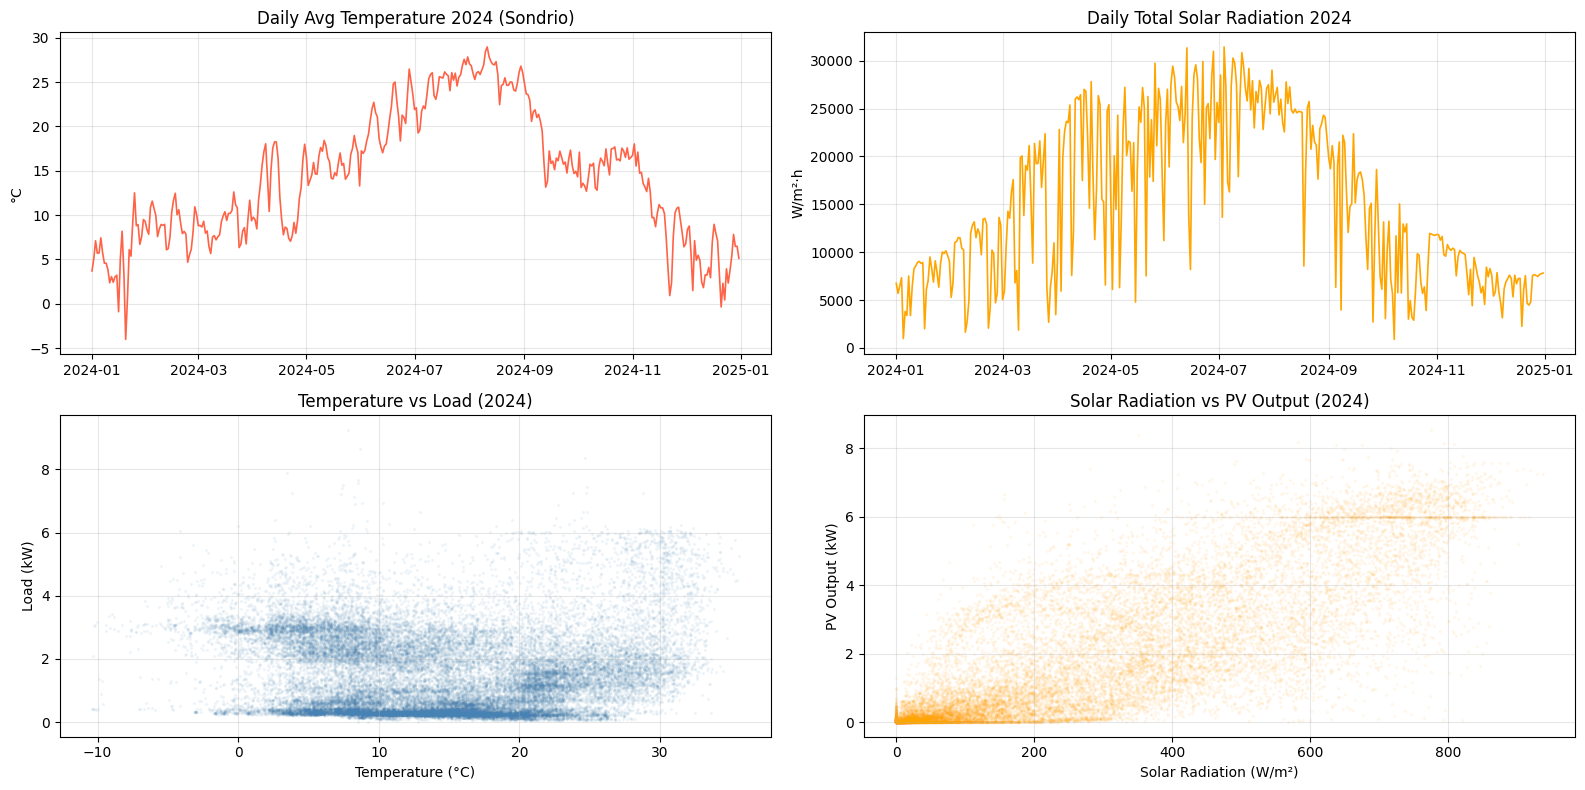

In [ ]:
# ── Weather EDA ────────────────────────────────────────────────
w24 = weather_df[weather_df['timestamp'].dt.year == 2024]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

daily_temp = w24.set_index('timestamp')['temp_c'].resample('D').mean()
axes[0,0].plot(daily_temp.index, daily_temp.values, color='tomato', linewidth=1.2)
axes[0,0].set_title('Daily Avg Temperature 2024 (Sondrio)')
axes[0,0].set_ylabel('°C')

daily_rad = w24.set_index('timestamp')['solar_radiation_wm2'].resample('D').sum()
axes[0,1].plot(daily_rad.index, daily_rad.values, color='orange', linewidth=1.2)
axes[0,1].set_title('Daily Total Solar Radiation 2024')
axes[0,1].set_ylabel('W/m²·h')

merged_temp = w24.merge(df_2024[['timestamp','load_kw']], on='timestamp', how='inner').dropna()
axes[1,0].scatter(merged_temp['temp_c'], merged_temp['load_kw'], alpha=0.05, s=2, color='steelblue')
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Load (kW)')
axes[1,0].set_title('Temperature vs Load (2024)')

merged_rad = w24.merge(df_2024[['timestamp','pv_kw']], on='timestamp', how='inner').dropna()
axes[1,1].scatter(merged_rad['solar_radiation_wm2'], merged_rad['pv_kw'], alpha=0.05, s=2, color='orange')
axes[1,1].set_xlabel('Solar Radiation (W/m²)')
axes[1,1].set_ylabel('PV Output (kW)')
axes[1,1].set_title('Solar Radiation vs PV Output (2024)')

plt.tight_layout()
plt.savefig('eda_08_weather.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Engineering (2024)

In [ ]:
# ── Tariff bands ───────────────────────────────────────────────
it_holidays = holidays.Italy(years=[2024])

def get_tariff_band(ts):
    date = ts.date(); hour = ts.hour; dow = ts.weekday()
    is_hol = date in it_holidays
    if is_hol or dow == 6: return 'F3', 0.2440
    if dow == 5:
        return ('F2', 0.2682) if 7 <= hour < 23 else ('F3', 0.2440)
    if 8 <= hour < 19:  return 'F1', 0.2540
    if (7 <= hour < 8) or (19 <= hour < 23): return 'F2', 0.2682
    return 'F3', 0.2440

tariff = df_raw['timestamp'].apply(get_tariff_band)
df_raw['current_band'] = tariff.apply(lambda x: x[0])
df_raw['buy_price']    = tariff.apply(lambda x: x[1])

print('Tariff band distribution:')
print(df_raw['current_band'].value_counts())

# ── Merge weather ──────────────────────────────────────────────
weather_2024 = weather_df[weather_df['timestamp'].dt.year == 2024].copy()
df_feat = df_raw.merge(weather_2024, on='timestamp', how='left')
print(f'\nShape after weather merge: {df_feat.shape}')
print(f'Nulls after merge: {df_feat.isnull().sum().sum()}')

Tariff band distribution:
current_band
F3    15612
F1    11176
F2     8344
Name: count, dtype: int64

Shape after weather merge: (35132, 26)
Nulls after merge: 864


In [ ]:
# ══════════════════════════════════════════════════════════════
# GROUP 1 — Time/Calendar Features
# All time features are known before the day starts — no leakage
# ══════════════════════════════════════════════════════════════

df_feat['hour']            = df_feat['timestamp'].dt.hour
df_feat['minute']          = df_feat['timestamp'].dt.minute
df_feat['quarter_of_hour'] = df_feat['minute'] // 15
df_feat['step_of_day']     = df_feat['hour'] * 4 + df_feat['quarter_of_hour']  # 0-95
df_feat['dow']             = df_feat['timestamp'].dt.dayofweek
df_feat['month']           = df_feat['timestamp'].dt.month
df_feat['day_of_year']     = df_feat['timestamp'].dt.dayofyear
df_feat['week_of_year']    = df_feat['timestamp'].dt.isocalendar().week.astype(int)
df_feat['quarter']         = df_feat['timestamp'].dt.quarter
df_feat['is_weekend']      = (df_feat['dow'] >= 5).astype(int)
df_feat['is_holiday']      = df_feat['timestamp'].dt.date.map(lambda d: int(d in it_holidays))
df_feat['is_working_day']  = ((df_feat['is_weekend']==0) & (df_feat['is_holiday']==0)).astype(int)

holiday_dates = set(it_holidays.keys())

def days_to_next_holiday(ts):
    d = ts.date()
    for i in range(1, 8):
        if (d + pd.Timedelta(days=i)) in holiday_dates: return i
    return 7

def days_since_last_holiday(ts):
    d = ts.date()
    for i in range(1, 8):
        if (d - pd.Timedelta(days=i)) in holiday_dates: return i
    return 7

unique_dates = df_feat['timestamp'].dt.date.unique()
df_feat['days_until_holiday'] = df_feat['timestamp'].dt.date.map(
    {d: days_to_next_holiday(pd.Timestamp(d)) for d in unique_dates})
df_feat['days_after_holiday'] = df_feat['timestamp'].dt.date.map(
    {d: days_since_last_holiday(pd.Timestamp(d)) for d in unique_dates})

# Fourier cyclical encoding
df_feat['sin_hour']  = np.sin(2*np.pi*df_feat['step_of_day']/96)
df_feat['cos_hour']  = np.cos(2*np.pi*df_feat['step_of_day']/96)
df_feat['sin_dow']   = np.sin(2*np.pi*df_feat['dow']/7)
df_feat['cos_dow']   = np.cos(2*np.pi*df_feat['dow']/7)
df_feat['sin_month'] = np.sin(2*np.pi*df_feat['month']/12)
df_feat['cos_month'] = np.cos(2*np.pi*df_feat['month']/12)
df_feat['sin_doy']   = np.sin(2*np.pi*df_feat['day_of_year']/365)
df_feat['cos_doy']   = np.cos(2*np.pi*df_feat['day_of_year']/365)

print('✅ Group 1 — Time/Calendar features done')

✅ Group 1 — Time/Calendar features done


In [ ]:
# ══════════════════════════════════════════════════════════════
# GROUP 2 — Domain/Tariff Features
# All tariff features are known before the day starts
# ══════════════════════════════════════════════════════════════

band_map = {'F1':1,'F2':2,'F3':3}
df_feat['band_int']              = df_feat['current_band'].map(band_map)
df_feat['next_band_int']         = df_feat['band_int'].shift(-1).fillna(3).astype(int)
df_feat['is_band_changing_next'] = (df_feat['band_int'] != df_feat['next_band_int']).astype(int)

band_change_mask = df_feat['is_band_changing_next'].values
mins_until = np.zeros(len(df_feat)); countdown = 0
for i in range(len(df_feat)-1, -1, -1):
    countdown = 0 if band_change_mask[i]==1 else countdown+15
    mins_until[i] = countdown
df_feat['mins_until_band_change'] = mins_until

# Sell price — use yesterday's price (known before today)
df_feat['sell_price_lag_96']    = df_feat['sell_price'].shift(96)
df_feat['price_spread']         = df_feat['buy_price'] - df_feat['sell_price'].shift(96)
df_feat['is_export_profitable'] = (df_feat['sell_price'].shift(96) > 0.15).astype(int)
df_feat['is_solar_hour']        = ((df_feat['hour']>=7) & (df_feat['hour']<=20)).astype(int)

# PV lags — yesterday and last week (known before today)
df_feat['pv_lag_96']  = df_feat['pv_kw'].shift(96)
df_feat['pv_lag_672'] = df_feat['pv_kw'].shift(672)

print('✅ Group 2 — Domain/Tariff features done')

✅ Group 2 — Domain/Tariff features done


In [ ]:
# ══════════════════════════════════════════════════════════════
# GROUP 3 — Lag & Rolling Features
# WINDOW = 1 day → ALL lags ≥ 96 steps (24 hours)
# This ensures the optimizer can plan a full day ahead
# ══════════════════════════════════════════════════════════════

# Daily lags — all ≥ 24 hours
df_feat['load_lag_96']  = df_feat['load_kw'].shift(96)    # yesterday same time
df_feat['load_lag_192'] = df_feat['load_kw'].shift(192)   # 2 days ago
df_feat['load_lag_672'] = df_feat['load_kw'].shift(672)   # 1 week ago

# Rolling stats — all computed from yesterday backwards
df_feat['rolling_mean_96']  = df_feat['load_kw'].shift(96).rolling(96).mean()    # yesterday avg
df_feat['rolling_std_96']   = df_feat['load_kw'].shift(96).rolling(96).std()     # yesterday std
df_feat['rolling_max_96']   = df_feat['load_kw'].shift(96).rolling(96).max()     # yesterday peak
df_feat['rolling_min_96']   = df_feat['load_kw'].shift(96).rolling(96).min()     # yesterday trough
df_feat['rolling_mean_192'] = df_feat['load_kw'].shift(96).rolling(192).mean()   # 2-day avg
df_feat['rolling_mean_672'] = df_feat['load_kw'].shift(96).rolling(672).mean()   # 1-week avg
df_feat['rolling_std_672']  = df_feat['load_kw'].shift(96).rolling(672).std()    # 1-week std

# Same step of day — average over last 7 days (shift(7) = 7 occurrences of same step)
df_feat['rolling_mean_same_hour_7d'] = (
    df_feat.groupby('step_of_day')['load_kw']
    .transform(lambda x: x.shift(7).rolling(7, min_periods=1).mean())
)

# Daily total load from yesterday
df_feat['date'] = df_feat['timestamp'].dt.date
daily_load = df_feat.groupby('date')['load_kw'].sum().reset_index()
daily_load.columns = ['date', 'daily_load_total']
daily_load['date'] = pd.to_datetime(daily_load['date']) + pd.Timedelta(days=1)
daily_load['date'] = daily_load['date'].dt.date
df_feat = df_feat.merge(daily_load, on='date', how='left')

# Daily peak from yesterday
daily_peak = df_feat.groupby('date')['load_kw'].max().reset_index()
daily_peak.columns = ['date', 'daily_peak_yesterday']
daily_peak['date'] = pd.to_datetime(daily_peak['date']) + pd.Timedelta(days=1)
daily_peak['date'] = daily_peak['date'].dt.date
df_feat = df_feat.merge(daily_peak, on='date', how='left')
df_feat = df_feat.drop(columns=['date'])

print('✅ Group 3 — Lag & Rolling features done (all lags ≥ 96 steps)')

✅ Group 3 — Lag & Rolling features done (all lags ≥ 96 steps)


In [ ]:
# ══════════════════════════════════════════════════════════════
# GROUP 4 — Extra Features
# All derived from past data only (≥ 24 hours ago)
# ══════════════════════════════════════════════════════════════

# Temperature interactions — current temp is exogenous (weather forecast known before day)
df_feat['temp_x_step']   = df_feat['temp_c'] * df_feat['step_of_day']
df_feat['temp_x_iswork'] = df_feat['temp_c'] * df_feat['is_working_day']

# Load z-score — computed using load from 7 days ago same step (fully causal)
df_feat['load_z_step'] = (
    df_feat.groupby('step_of_day')['load_kw']
    .transform(lambda x: (x.shift(7) - x.shift(7).mean()) / (x.shift(7).std() + 1e-6))
)

# EWMA — using load from 24 hours ago
df_feat['load_ewma_24h'] = df_feat['load_kw'].shift(96).ewm(span=96,  adjust=False).mean()
df_feat['load_ewma_7d']  = df_feat['load_kw'].shift(96).ewm(span=672, adjust=False).mean()

# Net load — load minus PV from 24 hours ago
df_feat['net_load_lag_96']   = (df_feat['load_kw'] - df_feat['pv_kw']).shift(96)
df_feat['net_load_lag_672']  = (df_feat['load_kw'] - df_feat['pv_kw']).shift(672)

# PV surplus yesterday
df_feat['pv_surplus_lag_96'] = (df_feat['pv_kw'] - df_feat['load_kw']).clip(lower=0).shift(96)

# Load trend — yesterday vs last week same time
df_feat['load_trend_week'] = df_feat['load_lag_96'] - df_feat['load_lag_672']

print('✅ Group 4 — Extra features done (all ≥ 24h lag)')

✅ Group 4 — Extra features done (all ≥ 24h lag)


## 8. Save 2024 Features

In [ ]:
# ── Feature Summary ────────────────────────────────────────────
TARGET = 'load_kw'
EXCLUDE = [
    'timestamp', 'load_kw', 'p_battery_kw', 'p_grid_kw',
    'balance_error', 'balance_ok', 'current_band', 'sell_price'
]

FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE]

print(f'Total features: {len(FEATURE_COLS)}')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

# Null counts
null_counts = df_feat[FEATURE_COLS + [TARGET]].isnull().sum()
print('\nNull counts (features with nulls):')
print(null_counts[null_counts > 0].sort_values(ascending=False))

Total features: 72
   1. pv_kw
   2. buy_price
   3. temp_c
   4. humidity_pct
   5. cloud_cover_pct
   6. precipitation_mm
   7. solar_radiation_wm2
   8. windspeed_ms
   9. temp_lag_24h
  10. temp_lag_48h
  11. temp_ewma_24h
  12. is_hot_day
  13. is_cold_day
  14. temp_mean_yesterday
  15. temp_max_yesterday
  16. temp_min_yesterday
  17. radiation_sum_yesterday
  18. cloud_mean_yesterday
  19. hour
  20. minute
  21. quarter_of_hour
  22. step_of_day
  23. dow
  24. month
  25. day_of_year
  26. week_of_year
  27. quarter
  28. is_weekend
  29. is_holiday
  30. is_working_day
  31. days_until_holiday
  32. days_after_holiday
  33. sin_hour
  34. cos_hour
  35. sin_dow
  36. cos_dow
  37. sin_month
  38. cos_month
  39. sin_doy
  40. cos_doy
  41. band_int
  42. next_band_int
  43. is_band_changing_next
  44. mins_until_band_change
  45. sell_price_lag_96
  46. price_spread
  47. is_export_profitable
  48. is_solar_hour
  49. pv_lag_96
  50. pv_lag_672
  51. load_lag_96
  52. load_l

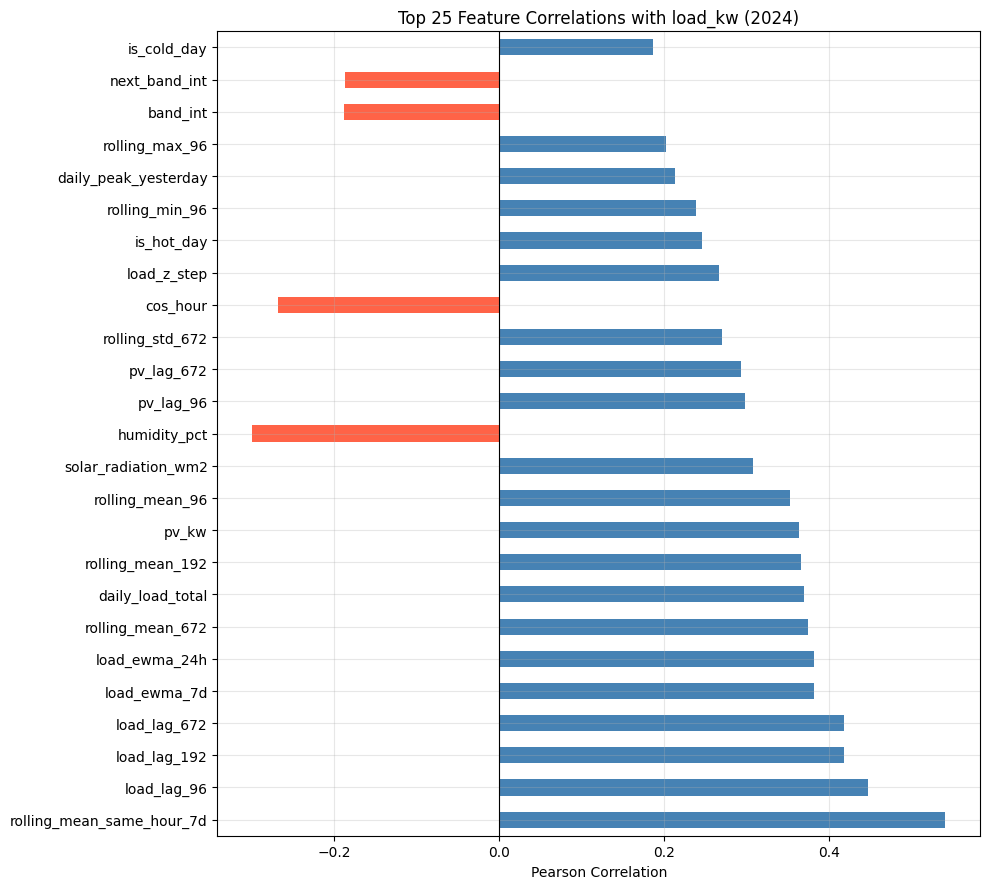

In [ ]:
# ── Feature Correlation with Target ───────────────────────────
corr_with_target = (
    df_feat[FEATURE_COLS + [TARGET]].corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

top_n = 25
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target.head(top_n).values]
corr_with_target.head(top_n).plot(kind='barh', ax=ax, color=colors)
ax.set_title(f'Top {top_n} Feature Correlations with load_kw (2024)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('eda_09_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Save 2024 Clean Feature File ──────────────────────────────
feat_2024_clean = df_feat.copy()

# Fill lag warm-up nulls
feat_2024_clean[FEATURE_COLS] = (
    feat_2024_clean[FEATURE_COLS]
    .fillna(method='bfill')
    .fillna(method='ffill')
)

print(f'2024 shape      : {feat_2024_clean.shape}')
print(f'Remaining nulls : {feat_2024_clean[FEATURE_COLS].isnull().sum().sum()}')

feat_2024_clean.to_csv('features_2024.csv', index=False)

with open('feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('\n✅ Saved:')
print('   features_2024.csv')
print('   feature_cols.json')

2024 shape      : (35132, 80)
Remaining nulls : 0

✅ Saved:
   features_2024.csv
   feature_cols.json


In [ ]:
# ── Verification ───────────────────────────────────────────────
df_check = pd.read_csv('features_2024.csv')
print(f'Rows    : {len(df_check)}  (expected ~35132)')
print(f'Columns : {len(df_check.columns)}')
print(f'Nulls   : {df_check.isnull().sum().sum()}  (should be 0)')

# Lag alignment check — lag_96 at row i should equal load_kw at row i-96
lag96_check = (df_check['load_lag_96'].iloc[96:].values == df_check['load_kw'].iloc[:-96].values)
print(f'\nlag_96 aligns with load_kw shifted by 96: {lag96_check.mean()*100:.2f}% match')

# Confirm no short lags
short_lags = ['load_lag_1','load_lag_2','load_lag_4','load_lag_8','load_lag_12','load_lag_16']
found = [c for c in short_lags if c in df_check.columns]
print(f'\nShort lags (< 24h) in features: {found}  (should be empty ✅)')
print('\n✅ Verification complete')

Rows    : 35132  (expected ~35132)
Columns : 80
Nulls   : 0  (should be 0)

lag_96 aligns with load_kw shifted by 96: 100.00% match

Short lags (< 24h) in features: []  (should be empty ✅)

✅ Verification complete


## 9. 2025 EDA & Feature Engineering

In [ ]:
# ── Load 2025 Raw Data ─────────────────────────────────────────
df_raw_full = pd.read_csv('/content/ENERGY_Hackathon_DataSet_Sheet1.csv', sep=';', decimal=',')
df_raw_full['timestamp'] = pd.to_datetime(df_raw_full['timestamp'])
df_raw_full = df_raw_full.rename(columns={
    'battery_p':'p_battery_kw','grid_p':'p_grid_kw',
    'load_p':'load_kw','pv_p':'pv_kw','Selling_price_eur_kwh':'sell_price'
})
df_raw_full = df_raw_full.sort_values('timestamp').reset_index(drop=True)

df_2025 = df_raw_full[df_raw_full['timestamp'].dt.year == 2025].copy().reset_index(drop=True)
df_2025['sell_price'] = df_2025['sell_price'].fillna(method='ffill')

# Remove duplicates
dups = df_2025.duplicated(subset='timestamp').sum()
if dups > 0:
    df_2025 = df_2025.drop_duplicates(subset='timestamp').reset_index(drop=True)

print(f'2025 rows  : {len(df_2025)}')
print(f'Date range : {df_2025.timestamp.min()} → {df_2025.timestamp.max()}')
print(f'Nulls      : {df_2025.isnull().sum().sum()}')

2025 rows  : 34941
Date range : 2025-01-01 00:00:00 → 2025-12-31 00:00:00
Nulls      : 0


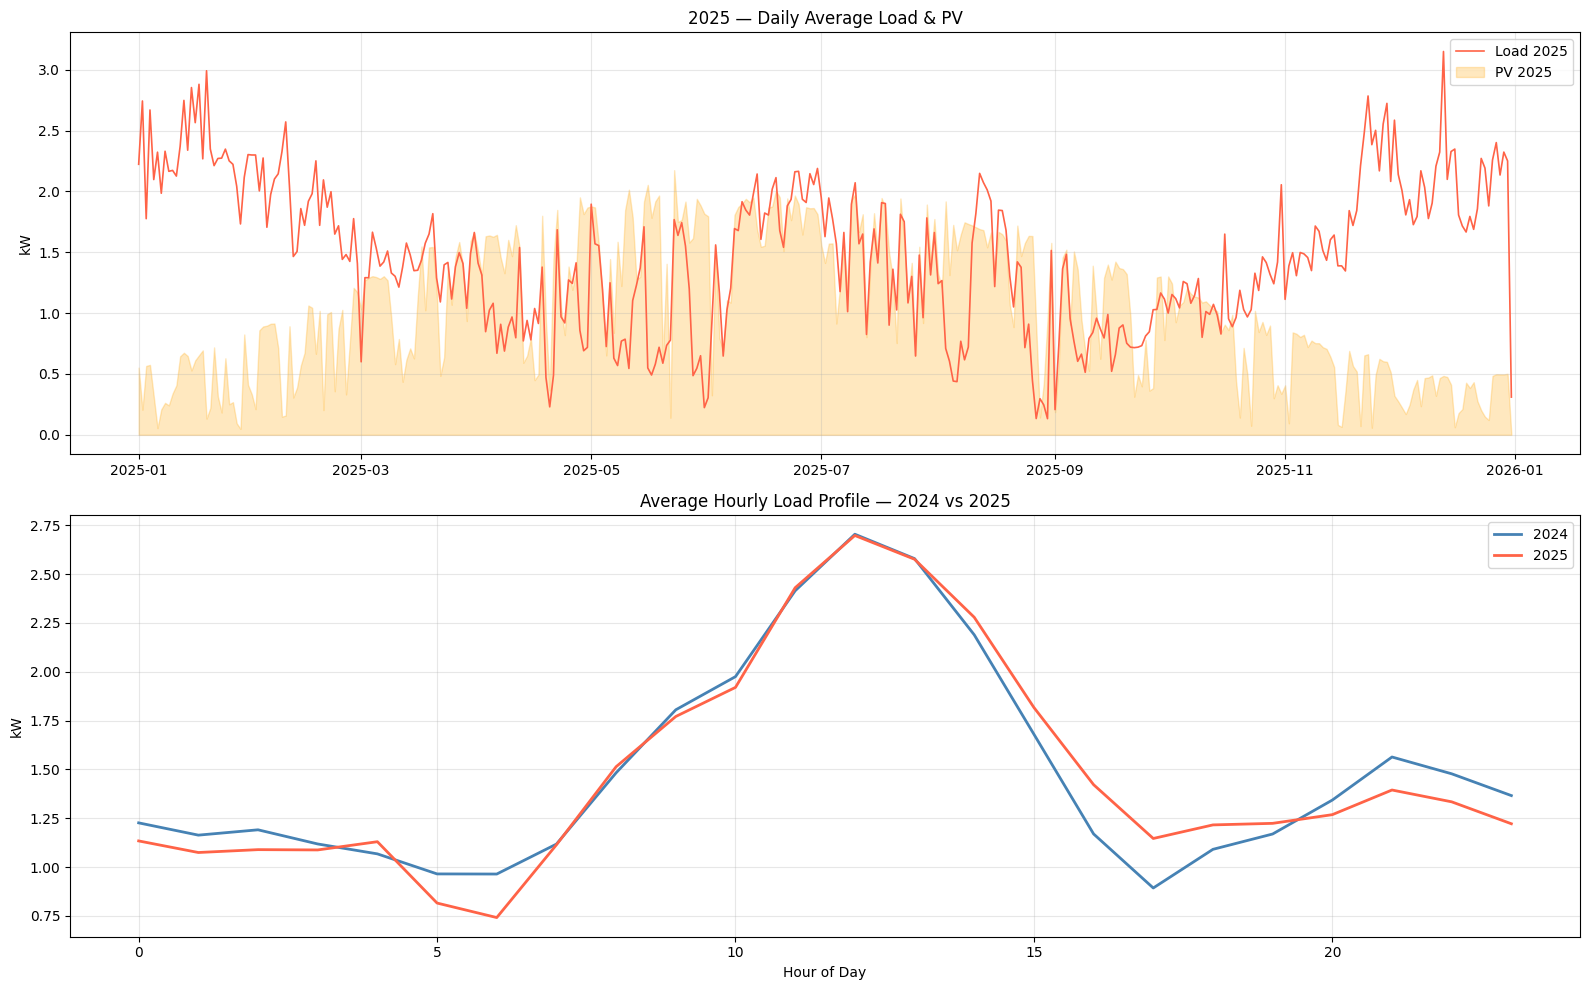

In [ ]:
# ── 2025 EDA ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

daily_2025 = df_2025.set_index('timestamp').resample('D')[['load_kw','pv_kw']].mean()
axes[0].plot(daily_2025.index, daily_2025['load_kw'], label='Load 2025', color='tomato',    linewidth=1.2)
axes[0].fill_between(daily_2025.index, daily_2025['pv_kw'], alpha=0.25, color='orange', label='PV 2025')
axes[0].set_title('2025 — Daily Average Load & PV')
axes[0].set_ylabel('kW')
axes[0].legend()

# 2024 vs 2025 hourly profile
df_2024_raw = df_raw_full[df_raw_full['timestamp'].dt.year == 2024].copy()
profile_2024 = df_2024_raw.groupby(df_2024_raw['timestamp'].dt.hour)['load_kw'].mean()
profile_2025 = df_2025.groupby(df_2025['timestamp'].dt.hour)['load_kw'].mean()
axes[1].plot(profile_2024.index, profile_2024.values, label='2024', color='steelblue', linewidth=2)
axes[1].plot(profile_2025.index, profile_2025.values, label='2025', color='tomato',    linewidth=2)
axes[1].set_title('Average Hourly Load Profile — 2024 vs 2025')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('kW')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_10_2025_overview.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Load 2025 Weather ──────────────────────────────────────────
weather_2025 = pd.read_csv('/content/Weather_2025.csv', sep=',', skiprows=3)
weather_2025 = weather_2025.rename(columns={
    'time'                               : 'timestamp',
    'temperature_2m (°C)'                : 'temp_c',
    'relative_humidity_2m (%)'           : 'humidity_pct',
    'cloud_cover (%)'                    : 'cloud_cover_pct',
    'precipitation (mm)'                 : 'precipitation_mm',
    'shortwave_radiation_instant (W/m²)' : 'solar_radiation_wm2',
    'wind_speed_10m (km/h)'              : 'windspeed_ms',
})
weather_2025['timestamp'] = pd.to_datetime(weather_2025['timestamp'])
weather_2025 = weather_2025.sort_values('timestamp').reset_index(drop=True)
weather_2025 = weather_2025.set_index('timestamp').resample('15min').interpolate(method='linear').reset_index()

# Derived weather — all ≥ 24h lag
weather_2025['temp_lag_24h']  = weather_2025['temp_c'].shift(96)
weather_2025['temp_lag_48h']  = weather_2025['temp_c'].shift(192)
weather_2025['temp_ewma_24h'] = weather_2025['temp_c'].shift(96).ewm(span=96, adjust=False).mean()
weather_2025['is_hot_day']    = (weather_2025['temp_c'] > 28).astype(int)
weather_2025['is_cold_day']   = (weather_2025['temp_c'] < 5).astype(int)

# Daily weather aggregates
weather_2025['date'] = weather_2025['timestamp'].dt.date
daily_weather_2025 = weather_2025.groupby('date').agg(
    temp_mean_yesterday     = ('temp_c', 'mean'),
    temp_max_yesterday      = ('temp_c', 'max'),
    temp_min_yesterday      = ('temp_c', 'min'),
    radiation_sum_yesterday = ('solar_radiation_wm2', 'sum'),
    cloud_mean_yesterday    = ('cloud_cover_pct', 'mean'),
).reset_index()
daily_weather_2025['date'] = pd.to_datetime(daily_weather_2025['date']) + pd.Timedelta(days=1)
daily_weather_2025['date'] = daily_weather_2025['date'].dt.date
weather_2025 = weather_2025.merge(daily_weather_2025, on='date', how='left')
weather_2025 = weather_2025.drop(columns=['date'])

print(f'2025 weather shape: {weather_2025.shape}')
print(f'Nulls             : {weather_2025.isnull().sum().sum()}')

2025 weather shape: (35037, 17)
Nulls             : 864


In [ ]:
# ── 2025 Tariff & Merge ────────────────────────────────────────
it_holidays_all = holidays.Italy(years=[2024, 2025])

tariff_2025 = df_2025['timestamp'].apply(get_tariff_band)
df_2025['current_band'] = tariff_2025.apply(lambda x: x[0])
df_2025['buy_price']    = tariff_2025.apply(lambda x: x[1])

weather_2025_only = weather_2025[weather_2025['timestamp'].dt.year == 2025].copy()
df_2025_feat = df_2025.merge(weather_2025_only, on='timestamp', how='left')
print(f'Shape after weather merge: {df_2025_feat.shape}')

# ── GROUP 1 — Time/Calendar ────────────────────────────────────
df_2025_feat['hour']            = df_2025_feat['timestamp'].dt.hour
df_2025_feat['minute']          = df_2025_feat['timestamp'].dt.minute
df_2025_feat['quarter_of_hour'] = df_2025_feat['minute'] // 15
df_2025_feat['step_of_day']     = df_2025_feat['hour']*4 + df_2025_feat['quarter_of_hour']
df_2025_feat['dow']             = df_2025_feat['timestamp'].dt.dayofweek
df_2025_feat['month']           = df_2025_feat['timestamp'].dt.month
df_2025_feat['day_of_year']     = df_2025_feat['timestamp'].dt.dayofyear
df_2025_feat['week_of_year']    = df_2025_feat['timestamp'].dt.isocalendar().week.astype(int)
df_2025_feat['quarter']         = df_2025_feat['timestamp'].dt.quarter
df_2025_feat['is_weekend']      = (df_2025_feat['dow'] >= 5).astype(int)
df_2025_feat['is_holiday']      = df_2025_feat['timestamp'].dt.date.map(lambda d: int(d in it_holidays_all))
df_2025_feat['is_working_day']  = ((df_2025_feat['is_weekend']==0) & (df_2025_feat['is_holiday']==0)).astype(int)

holiday_dates_all = set(it_holidays_all.keys())
unique_dates_2025 = df_2025_feat['timestamp'].dt.date.unique()
df_2025_feat['days_until_holiday'] = df_2025_feat['timestamp'].dt.date.map(
    {d: days_to_next_holiday(pd.Timestamp(d)) for d in unique_dates_2025})
df_2025_feat['days_after_holiday'] = df_2025_feat['timestamp'].dt.date.map(
    {d: days_since_last_holiday(pd.Timestamp(d)) for d in unique_dates_2025})

df_2025_feat['sin_hour']  = np.sin(2*np.pi*df_2025_feat['step_of_day']/96)
df_2025_feat['cos_hour']  = np.cos(2*np.pi*df_2025_feat['step_of_day']/96)
df_2025_feat['sin_dow']   = np.sin(2*np.pi*df_2025_feat['dow']/7)
df_2025_feat['cos_dow']   = np.cos(2*np.pi*df_2025_feat['dow']/7)
df_2025_feat['sin_month'] = np.sin(2*np.pi*df_2025_feat['month']/12)
df_2025_feat['cos_month'] = np.cos(2*np.pi*df_2025_feat['month']/12)
df_2025_feat['sin_doy']   = np.sin(2*np.pi*df_2025_feat['day_of_year']/365)
df_2025_feat['cos_doy']   = np.cos(2*np.pi*df_2025_feat['day_of_year']/365)
print('✅ Group 1 done')

# ── GROUP 2 — Domain/Tariff ────────────────────────────────────
band_map = {'F1':1,'F2':2,'F3':3}
df_2025_feat['band_int']              = df_2025_feat['current_band'].map(band_map)
df_2025_feat['next_band_int']         = df_2025_feat['band_int'].shift(-1).fillna(3).astype(int)
df_2025_feat['is_band_changing_next'] = (df_2025_feat['band_int']!=df_2025_feat['next_band_int']).astype(int)
band_change_mask = df_2025_feat['is_band_changing_next'].values
mins_until = np.zeros(len(df_2025_feat)); countdown=0
for i in range(len(df_2025_feat)-1,-1,-1):
    countdown = 0 if band_change_mask[i]==1 else countdown+15
    mins_until[i] = countdown
df_2025_feat['mins_until_band_change'] = mins_until
df_2025_feat['sell_price_lag_96']    = df_2025_feat['sell_price'].shift(96)
df_2025_feat['price_spread']         = df_2025_feat['buy_price'] - df_2025_feat['sell_price'].shift(96)
df_2025_feat['is_export_profitable'] = (df_2025_feat['sell_price'].shift(96) > 0.15).astype(int)
df_2025_feat['is_solar_hour']        = ((df_2025_feat['hour']>=7)&(df_2025_feat['hour']<=20)).astype(int)
df_2025_feat['pv_lag_96']            = df_2025_feat['pv_kw'].shift(96)
df_2025_feat['pv_lag_672']           = df_2025_feat['pv_kw'].shift(672)
print('✅ Group 2 done')

Shape after weather merge: (34941, 24)
✅ Group 1 done
✅ Group 2 done


In [ ]:
# ── GROUP 3 — Lags (combined 2024+2025) ───────────────────────
# Combine 2024+2025 so 2025 lags have 2024 history available
df_combined = pd.concat([
    df_raw_full[df_raw_full['timestamp'].dt.year==2024][['timestamp','load_kw','pv_kw']],
    df_2025_feat[['timestamp','load_kw','pv_kw']]
], ignore_index=True).sort_values('timestamp').reset_index(drop=True)

# All lags ≥ 96 steps
for lag in [96, 192, 672]:
    df_combined[f'load_lag_{lag}'] = df_combined['load_kw'].shift(lag)

df_combined['rolling_mean_96']  = df_combined['load_kw'].shift(96).rolling(96).mean()
df_combined['rolling_std_96']   = df_combined['load_kw'].shift(96).rolling(96).std()
df_combined['rolling_max_96']   = df_combined['load_kw'].shift(96).rolling(96).max()
df_combined['rolling_min_96']   = df_combined['load_kw'].shift(96).rolling(96).min()
df_combined['rolling_mean_192'] = df_combined['load_kw'].shift(96).rolling(192).mean()
df_combined['rolling_mean_672'] = df_combined['load_kw'].shift(96).rolling(672).mean()
df_combined['rolling_std_672']  = df_combined['load_kw'].shift(96).rolling(672).std()

df_combined['rolling_mean_same_hour_7d'] = (
    df_combined.groupby(df_combined['timestamp'].dt.hour*4 + df_combined['timestamp'].dt.minute//15)['load_kw']
    .transform(lambda x: x.shift(7).rolling(7, min_periods=1).mean())
)

# Daily aggregates
df_combined['date'] = df_combined['timestamp'].dt.date
daily_load_c = df_combined.groupby('date')['load_kw'].sum().reset_index()
daily_load_c.columns = ['date','daily_load_total']
daily_load_c['date'] = pd.to_datetime(daily_load_c['date']) + pd.Timedelta(days=1)
daily_load_c['date'] = daily_load_c['date'].dt.date
df_combined = df_combined.merge(daily_load_c, on='date', how='left')

daily_peak_c = df_combined.groupby('date')['load_kw'].max().reset_index()
daily_peak_c.columns = ['date','daily_peak_yesterday']
daily_peak_c['date'] = pd.to_datetime(daily_peak_c['date']) + pd.Timedelta(days=1)
daily_peak_c['date'] = daily_peak_c['date'].dt.date
df_combined = df_combined.merge(daily_peak_c, on='date', how='left')
df_combined = df_combined.drop(columns=['date'])

# Extract 2025 rows only
lag_cols = [c for c in df_combined.columns if c not in ['timestamp','load_kw','pv_kw']]
df_2025_lags = df_combined[df_combined['timestamp'].dt.year==2025][['timestamp']+lag_cols].reset_index(drop=True)
df_2025_feat = df_2025_feat.merge(df_2025_lags, on='timestamp', how='left')
print('✅ Group 3 done')

✅ Group 3 done


In [ ]:
# ── GROUP 4 — Extra ────────────────────────────────────────────
df_2025_feat['temp_x_step']      = df_2025_feat['temp_c'] * df_2025_feat['step_of_day']
df_2025_feat['temp_x_iswork']    = df_2025_feat['temp_c'] * df_2025_feat['is_working_day']
df_2025_feat['load_z_step']      = (
    df_2025_feat.groupby('step_of_day')['load_kw']
    .transform(lambda x: (x.shift(7) - x.shift(7).mean()) / (x.shift(7).std() + 1e-6))
)
df_2025_feat['load_ewma_24h']    = df_2025_feat['load_kw'].shift(96).ewm(span=96,  adjust=False).mean()
df_2025_feat['load_ewma_7d']     = df_2025_feat['load_kw'].shift(96).ewm(span=672, adjust=False).mean()
df_2025_feat['net_load_lag_96']  = (df_2025_feat['load_kw'] - df_2025_feat['pv_kw']).shift(96)
df_2025_feat['net_load_lag_672'] = (df_2025_feat['load_kw'] - df_2025_feat['pv_kw']).shift(672)
df_2025_feat['pv_surplus_lag_96']= (df_2025_feat['pv_kw'] - df_2025_feat['load_kw']).clip(lower=0).shift(96)
df_2025_feat['load_trend_week']  = df_2025_feat['load_lag_96'] - df_2025_feat['load_lag_672']
print('✅ Group 4 done')
print(f'\n2025 feature shape: {df_2025_feat.shape}')

✅ Group 4 done

2025 feature shape: (34941, 78)


## 10. Save 2025 Features

In [38]:
# ── Fill nulls & Save ──────────────────────────────────────────
FEATURE_COLS_2025 = [c for c in FEATURE_COLS if c in df_2025_feat.columns]

df_2025_feat[FEATURE_COLS_2025] = (
    df_2025_feat[FEATURE_COLS_2025]
    .fillna(method='bfill')
    .fillna(method='ffill')
)

print(f'2025 shape      : {df_2025_feat.shape}')
print(f'Remaining nulls : {df_2025_feat[FEATURE_COLS_2025].isnull().sum().sum()}')

df_2025_feat.to_csv('features_2025.csv', index=False)
print('\n✅ Saved: features_2025.csv')

print('\n=== NOTEBOOK 1 COMPLETE ===')
print(f'2024 features : features_2024.csv  ({len(feat_2024_clean)} rows, {len(FEATURE_COLS)} features)')
print(f'2025 features : features_2025.csv  ({len(df_2025_feat)} rows)')
print(f'Feature list  : feature_cols.json')
print()
print('Key design decision: ALL lags ≥ 96 steps (24 hours)')
print('  → Optimizer receives full day forecast every morning')
print('  → No intra-day information leakage')
print()
print('→ Proceed to Notebook 2: Forecasting & Results')

2025 shape      : (34941, 78)
Remaining nulls : 0

✅ Saved: features_2025.csv

=== NOTEBOOK 1 COMPLETE ===
2024 features : features_2024.csv  (35132 rows, 72 features)
2025 features : features_2025.csv  (34941 rows)
Feature list  : feature_cols.json

Key design decision: ALL lags ≥ 96 steps (24 hours)
  → Optimizer receives full day forecast every morning
  → No intra-day information leakage

→ Proceed to Notebook 2: Forecasting & Results
